<a href="https://colab.research.google.com/github/Yuliia-Safonova/DTA-2026/blob/main/project_store_sales_analysis/Store_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Аналіз продажів магазину

### Вхідний датасет (дані)

In [79]:
# Запусти цей блок, щоб отримати датасет
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300

categories = ['Молочне', 'Хліб та випічка', 'М\'ясо та риба', 'Овочі та фрукти', 'Напої']
products = {
    'Молочне':          ['Молоко 1л', 'Кефір 0.5л', 'Сир кисломолочний', 'Масло вершкове', 'Йогурт'],
    'Хліб та випічка':  ['Хліб білий', 'Батон', 'Булочка', 'Хліб житній', 'Круасан'],
    'М\'ясо та риба':   ['Куряче філе', 'Свинина', 'Ковбаса', 'Риба хек', 'Сосиски'],
    'Овочі та фрукти':  ['Картопля', 'Морква', 'Яблука', 'Банани', 'Помідори'],
    'Напої':            ['Вода 1.5л', 'Сік апельсиновий', 'Чай', 'Кава мелена', 'Лимонад'],
}
prices = {
    'Молоко 1л': 38, 'Кефір 0.5л': 22, 'Сир кисломолочний': 55, 'Масло вершкове': 95, 'Йогурт': 30,
    'Хліб білий': 28, 'Батон': 25, 'Булочка': 12, 'Хліб житній': 32, 'Круасан': 18,
    'Куряче філе': 165, 'Свинина': 210, 'Ковбаса': 145, 'Риба хек': 120, 'Сосиски': 98,
    'Картопля': 20, 'Морква': 15, 'Яблука': 45, 'Банани': 52, 'Помідори': 60,
    'Вода 1.5л': 18, 'Сік апельсиновий': 68, 'Чай': 85, 'Кава мелена': 155, 'Лимонад': 35,
}

chosen_cats = np.random.choice(categories, n, p=[0.25, 0.20, 0.20, 0.20, 0.15])
chosen_products = [np.random.choice(products[c]) for c in chosen_cats]

df_origin = pd.DataFrame({
    'transaction_id': range(1001, 1001 + n),
    'date':           pd.to_datetime(
                          np.random.choice(pd.date_range('2024-03-01', '2024-03-31'), n)
                      ),
    'hour':           np.random.choice(range(8, 21), n, p=[0.04,0.06,0.08,0.10,0.12,0.12,0.11,0.10,0.09,0.08,0.06,0.04,0.00]),
    'category':       chosen_cats,
    'product':        chosen_products,
    'quantity':       np.random.randint(1, 6, n),
    'price_uah':      [prices[p] for p in chosen_products],
    'customer_age':   np.random.randint(18, 70, n),
    'payment':        np.random.choice(['Готівка', 'Картка', 'Телефон'], n, p=[0.35, 0.50, 0.15]),
})


In [80]:
df = df_origin.copy()

In [81]:
df

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment
0,1001,2024-03-17,17,Хліб та випічка,Круасан,4,18,28,Готівка
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка
2,1003,2024-03-01,18,Овочі та фрукти,Яблука,1,45,43,Картка
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка
...,...,...,...,...,...,...,...,...,...
295,1296,2024-03-08,10,М'ясо та риба,Сосиски,4,98,48,Готівка
296,1297,2024-03-05,13,Овочі та фрукти,Морква,5,15,28,Телефон
297,1298,2024-03-04,11,Молочне,Молоко 1л,3,38,27,Картка
298,1299,2024-03-24,14,М'ясо та риба,Ковбаса,1,145,20,Готівка


## Блок 1 - Перше знайомство з даними

1. Виведи перші 7 рядків датафрейму.


In [82]:
print(df.head(7))

   transaction_id       date  hour         category         product  quantity  \
0            1001 2024-03-17    17  Хліб та випічка         Круасан         4   
1            1002 2024-03-13    14            Напої     Кава мелена         3   
2            1003 2024-03-01    18  Овочі та фрукти          Яблука         1   
3            1004 2024-03-02     8    М'ясо та риба        Риба хек         3   
4            1005 2024-03-09    19          Молочне          Йогурт         5   
5            1006 2024-03-03    13          Молочне      Кефір 0.5л         3   
6            1007 2024-03-31    15          Молочне  Масло вершкове         2   

   price_uah  customer_age  payment  
0         18            28  Готівка  
1        155            40   Картка  
2         45            43   Картка  
3        120            51  Готівка  
4         30            63   Картка  
5         22            51   Картка  
6         95            46  Телефон  


In [83]:
df.head(7)  # display(df.head(7))

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment
0,1001,2024-03-17,17,Хліб та випічка,Круасан,4,18,28,Готівка
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка
2,1003,2024-03-01,18,Овочі та фрукти,Яблука,1,45,43,Картка
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка
5,1006,2024-03-03,13,Молочне,Кефір 0.5л,3,22,51,Картка
6,1007,2024-03-31,15,Молочне,Масло вершкове,2,95,46,Телефон


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  300 non-null    int64         
 1   date            300 non-null    datetime64[ns]
 2   hour            300 non-null    int64         
 3   category        300 non-null    object        
 4   product         300 non-null    object        
 5   quantity        300 non-null    int64         
 6   price_uah       300 non-null    int64         
 7   customer_age    300 non-null    int64         
 8   payment         300 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 21.2+ KB


In [85]:
type(df.price_uah) # df['price_uah']

pandas.core.series.Series

In [86]:
# type(df[['price_uah', 'quantity']])
type(df[['price_uah']])

pandas.core.frame.DataFrame

In [87]:
df['total_uah'] = df.quantity * df.price_uah

2. Дізнайся розмір таблиці (рядки × стовпці).

In [88]:
print(f"Розмір таблиці: {df.shape[0]} рядків х {df.shape[1]} стовпців")

Розмір таблиці: 300 рядків х 10 стовпців


3. Виведи типи даних кожного стовпця.

In [89]:
df.dtypes

,0
transaction_id,int64
date,datetime64[ns]
hour,int64
category,object
product,object
quantity,int64
price_uah,int64
customer_age,int64
payment,object
total_uah,int64


In [90]:
print("Типи даних:")
display(df.dtypes)

Типи даних:


,0
transaction_id,int64
date,datetime64[ns]
hour,int64
category,object
product,object
quantity,int64
price_uah,int64
customer_age,int64
payment,object
total_uah,int64


4. Перевір, чи є пропущені значення.

In [91]:
print(f"Пропущені значення (по стовпцям):\n\n{df.isnull().sum()}")

Пропущені значення (по стовпцям):

transaction_id    0
date              0
hour              0
category          0
product           0
quantity          0
price_uah         0
customer_age      0
payment           0
total_uah         0
dtype: int64


5. Виведи основну статистику (describe) для числових стовпців.

In [92]:
print("Статистика:\n")
df.describe().round(2)

Статистика:



,transaction_id,date,hour,quantity,price_uah,customer_age,total_uah
count,300.00,300,300.00,300.00,300.00,300.0,300.00
mean,1150.50,2024-03-16 02:14:24,13.72,2.97,63.45,43.0,186.97
min,1001.00,2024-03-01 00:00:00,8.00,1.00,12.00,18.0,12.00
25%,1075.75,2024-03-08 00:00:00,12.00,2.00,22.00,31.0,60.00
50%,1150.50,2024-03-16 12:00:00,14.00,3.00,38.00,42.5,120.00
75%,1225.25,2024-03-24 00:00:00,16.00,4.00,95.75,55.0,256.25
max,1300.00,2024-03-31 00:00:00,19.00,5.00,210.00,69.0,840.00
std,86.75,NaN,2.74,1.44,51.68,14.6,180.27


> **ВИСНОВОК**:  
Датасет містить інформацію про 300 транзакцій, 10 стовпців, пропущених значень немає.  
Середня сума чеку - 186.97 грн.  
Мінімальний чек - 12.00 грн. ().  
Максимальний чек - 840.00 грн. ().  
Підозрілих даних не виявлено.

###### Розбір

```
[1, 7, 9, 10, 12, 15]
```
Медіана: (9 + 10) / 2 = 9,5
```
[1, 7, 9, 10, 12, 15, 20]
```
Медіана: 10

---
```
[1, 7, 9, 10, 12, 15, 20]
```
Медіана: 10 - `50%`  
`min` = 1  
`max` = 20  
`count` = 7  
`mean` = 10.57  
`25%` ->  
0% - min -> 25% -> 50% - median -> 75% -> 100% - max
std ->  
10.57 - 1 = 9.57
10.57 - 7 = 3.57
..
20 - 10.57 = 9.43

`[1, 1, 1, 1, 1, 6, 7, 8, 9, 10]`
1% - min -> 1  
25% -> 1  
50% - median -> 3.5  
75% -> 8  
100% - max -> 10

s = [1, 7, 9, 10, 12, 15, 20]
mean = sum(s)/len(s)
mean

s = [1, 1, 1, 1, 1, 1, 1000]  
mean = sum(s)/len(s)  
mean  
std -> 143.71 - 1 = 142.71  
mediana = 1  

## Блок 2 - Фільтрація та відбір

1. Відбери всі покупки категорії «М'ясо та риба».

In [93]:
df[df['category'] == "М'ясо та риба"].head()

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка,360
8,1009,2024-03-21,15,М'ясо та риба,Ковбаса,2,145,34,Картка,290
17,1018,2024-03-06,14,М'ясо та риба,Куряче філе,3,165,69,Картка,495
20,1021,2024-03-23,9,М'ясо та риба,Куряче філе,3,165,64,Телефон,495
24,1025,2024-03-10,14,М'ясо та риба,Свинина,4,210,28,Картка,840


In [94]:
meat_fish = df[df['category'] == "М'ясо та риба"]
print(f'У категорії "М\'ясо та риба": {len(meat_fish)} транзакції')

У категорії "М'ясо та риба": 61 транзакції


2. Знайди транзакції, де сума (total_uah) перевищує 500 грн.

In [95]:
big = df[df['total_uah'] > 500]
print(f'Покупки > 500 грн: {len(big)} разів\n')
# print(big[['product', 'quantity', 'total_uah']].head())
display(big[['product', 'quantity', 'total_uah']].head())

Покупки > 500 грн: 17 разів



,product,quantity,total_uah
24,Свинина,4,840
28,Куряче філе,4,660
81,Ковбаса,4,580
89,Риба хек,5,600
93,Свинина,3,630


Відсоток великих покупок

In [96]:
pct_big = len(big) / len(df) * 100
# round(pct_big, 1)
print(f"Частка покупок > 500: {pct_big:.1f} %")

Частка покупок > 500: 5.7 %


In [97]:
for cat in big.category.unique():
    print(f"{cat} - {big[big['category'] == cat].count()}")

М'ясо та риба - transaction_id    14
date              14
hour              14
category          14
product           14
quantity          14
price_uah         14
customer_age      14
payment           14
total_uah         14
dtype: int64
Напої - transaction_id    3
date              3
hour              3
category          3
product           3
quantity          3
price_uah         3
customer_age      3
payment           3
total_uah         3
dtype: int64


3. Відбери покупки, зроблені карткою (payment == 'Картка'), кількістю більше 2 одиниць.

In [98]:
card_mult = df[(df['payment'] == 'Картка') & (df['quantity'] > 2)]
print("Картка + кількість > 2:", len(card_mult), "\n")
card_mult.head()

Картка + кількість > 2: 92 



,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка,465
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка,150
5,1006,2024-03-03,13,Молочне,Кефір 0.5л,3,22,51,Картка,66
10,1011,2024-03-23,13,Молочне,Сир кисломолочний,5,55,30,Картка,275
17,1018,2024-03-06,14,М'ясо та риба,Куряче філе,3,165,69,Картка,495


4. Знайди всі покупки покупців молодше 25 років.

In [99]:
young = df[df['customer_age'] < 25]
print("Покупців до 25: ", len(young), "\n")
young.head()

Покупців до 25:  36 



,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
7,1008,2024-03-01,17,Напої,Сік апельсиновий,1,68,21,Готівка,68
19,1020,2024-03-21,16,Хліб та випічка,Круасан,1,18,19,Готівка,18
26,1027,2024-03-19,13,Молочне,Йогурт,3,30,20,Готівка,90
36,1037,2024-03-04,14,Хліб та випічка,Круасан,1,18,23,Телефон,18
38,1039,2024-03-01,10,Овочі та фрукти,Помідори,1,60,22,Готівка,60


5. Скільки унікальних товарів є в датасеті?

In [100]:
n_unique = df['product'].nunique() # кількість унікальних товарів
# n_unique

pr_unique = df['product'].unique() # перелік унікальних товарів
# pr_unique

print("Кількість унікальних товарів:", n_unique, "\n")
print("Перелік унікальних товарів:", pr_unique, "\n")

Кількість унікальних товарів: 25 

Перелік унікальних товарів: [np.str_('Круасан') np.str_('Кава мелена') np.str_('Яблука')
 np.str_('Риба хек') np.str_('Йогурт') np.str_('Кефір 0.5л')
 np.str_('Масло вершкове') np.str_('Сік апельсиновий') np.str_('Ковбаса')
 np.str_('Картопля') np.str_('Сир кисломолочний') np.str_('Морква')
 np.str_('Куряче філе') np.str_('Хліб житній') np.str_('Батон')
 np.str_('Хліб білий') np.str_('Свинина') np.str_('Сосиски')
 np.str_('Молоко 1л') np.str_('Помідори') np.str_('Лимонад')
 np.str_('Булочка') np.str_('Банани') np.str_('Вода 1.5л') np.str_('Чай')] 



> **ВИСНОВОК**:  
Близько половини покупок оплачено карткою, з яких 1/3 має більше 2-х товарів у чеку.  
5.7 % транзакцій перевищують чек у розмірі 500 грн., здебільше це - категорія "М'ясо та риба".  
12 % покупців віком до 25 років.

## Блок 3 - Групування та агрегація

1. Підрахуй загальний виторг по кожній категорії. Відсортуй за спаданням.

In [101]:
df.groupby('category')['total_uah'].sum().sort_values(ascending=False)

,total_uah
category,
М'ясо та риба,25223
Напої,10389
Молочне,10075
Овочі та фрукти,6270
Хліб та випічка,4134


In [102]:
df.groupby('category').agg({
    'total_uah': 'sum',
    'transaction_id': 'count',
    'quantity': 'sum'
})

,total_uah,transaction_id,quantity
category,,,
М'ясо та риба,25223,61,186
Молочне,10075,80,242
Напої,10389,48,129
Овочі та фрукти,6270,55,158
Хліб та випічка,4134,56,177


In [103]:
df.groupby('category').agg({
    'total_uah': 'sum',
    'transaction_id': 'count',
    'quantity': 'sum'
}).sort_values(by=['total_uah', 'transaction_id'], ascending=False)

,total_uah,transaction_id,quantity
category,,,
М'ясо та риба,25223,61,186
Напої,10389,48,129
Молочне,10075,80,242
Овочі та фрукти,6270,55,158
Хліб та випічка,4134,56,177


2. Знайди топ-5 товарів за кількістю проданих одиниць (сума quantity).

In [104]:
#top_products = df.groupby('product')['quantity'].sum().sort_values(ascending=False).head()

print("ТОП-5 продуктів за кількістю проданих одиниць:\n")
df.groupby('product')['quantity'].sum().sort_values(ascending=False).head()

ТОП-5 продуктів за кількістю проданих одиниць:



,quantity
product,
Кефір 0.5л,63
Сосиски,61
Йогурт,57
Сир кисломолочний,54
Риба хек,48


3. Порівняй середню суму покупки для різних способів оплати.

In [105]:
print("Середній чек по оплаті:")
df.groupby('payment')["total_uah"].mean().round(2)

Середній чек по оплаті:


,total_uah
payment,
Готівка,175.16
Картка,205.26
Телефон,144.82


4. Згрупуй по hour - знайди, в які години відбувається найбільше транзакцій.

In [106]:
df. groupby('hour').size()

,0
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [107]:
df['hour'].value_counts().sort_index()

,count
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [108]:
print("Транзакції по годинах (за кількістю транзакцій):\n")
df['hour'].value_counts()

Транзакції по годинах (за кількістю транзакцій):



,count
hour,
14,44
13,41
16,32
12,30
11,30
15,27
17,26
10,23
18,19


5. Знайди день місяця з найвищим виторгом.

In [109]:
df['date'].dt.day

,date
0,17
1,13
2,1
3,2
4,9
...,...
295,8
296,5
297,4
298,24


In [110]:
df['day'] = df['date'].dt.day
best_day = df.groupby('day')['total_uah'].sum().idxmax()
best_revenue = df.groupby('day')['total_uah'].sum().max()

print(f"Найкращий день: {best_day} березня - {best_revenue:.2f} грн.")

Найкращий день: 2 березня - 3371.00 грн.


In [111]:
df.groupby('day')["total_uah"].sum().sort_values(ascending=False).head(1)

,total_uah
day,
2,3371


> **ВИСНОВОК**:  
Найприбутковіша категорія - "М'ясо та риба" (висока ціна).  
Найчастіше купують - молочну продукцію, особливо - Кефір 0.5л.
Пікові години торгівлі - з 13:00 до 14:00 години, проте приріст клієнтів починається вже з 11:00 години.  
Покупці, що здійснюють транзакції за допомогою картки, мають в середньому більший чек, ніж ті, хто оплачує готівкою.

## Блок 4 - Нові стовпці та трансформація

1. Додай стовпець revenue_share - частка виторгу кожної транзакції від загального виторгу (у відсотках).

In [112]:
total_revenue = df.total_uah.sum()
df['revenue_share'] = (df.total_uah / total_revenue * 100).round(4)
df[['product', 'total_uah', 'revenue_share']].head()

,product,total_uah,revenue_share
0,Круасан,72,0.1284
1,Кава мелена,465,0.8290
2,Яблука,45,0.0802
3,Риба хек,360,0.6418
4,Йогурт,150,0.2674


2. Додай стовпець age_group:  
        'Молодь' - до 30 років  
        'Середній вік' - 30–50 років  
        'Старші' - понад 50 років

In [113]:
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0, 30, 50, 100],
    labels=['Молодь', 'Середній вік', 'Старші'],
    right=False # [0, 30), [30, 50), [50, 100)
)

print("Розподіл по віковим групам:\n")
df.age_group.value_counts()

Розподіл по віковим групам:



,count
age_group,
Середній вік,120
Старші,111
Молодь,69


3. Додай стовпець weekday - день тижня з колонки date.

In [114]:
df['weekday'] = df.date.dt.day_name()
df.weekday.value_counts()

,count
weekday,
Sunday,55
Saturday,51
Friday,48
Tuesday,43
Wednesday,35
Monday,35
Thursday,33


4. Додай булевий стовпець is_big_purchase - True, якщо total_uah > 300.

In [115]:
df['is_big_purchase'] = df.total_uah > 300
pct = df['is_big_purchase'].mean() * 100
print(f'Частка \'великих\' покупок (> 300): {pct:.1f}%')

Частка 'великих' покупок (> 300): 19.3%


In [116]:
# Розподіл по віковим групам
print("Середній чек по віковим групам:\n")
df.groupby('age_group', observed=True)['total_uah'].mean()

Середній чек по віковим групам:



,total_uah
age_group,
Молодь,157.724638
Середній вік,196.608333
Старші,194.729730


In [117]:
# Розподіл по віковим групам
print("Середній чек по віковим групамі кількість 'великих' покупок:\n")
df.groupby('age_group', observed=True).agg({
    'total_uah': 'mean',
    'is_big_purchase': 'sum'
})

Середній чек по віковим групамі кількість 'великих' покупок:



,total_uah,is_big_purchase
age_group,,
Молодь,157.724638,9
Середній вік,196.608333,28
Старші,194.729730,21


> **ВИСНОВОК**:  
Яка вікова група робить найбільше покупок? Скільки % покупок є «великими»?

## Блок 5 - Візуалізація

In [118]:
df.columns

Index(['transaction_id', 'date', 'hour', 'category', 'product', 'quantity',
       'price_uah', 'customer_age', 'payment', 'total_uah', 'day',
       'revenue_share', 'age_group', 'weekday', 'is_big_purchase'],
      dtype='object')

1. Стовпчаста діаграма - виторг по категоріях.

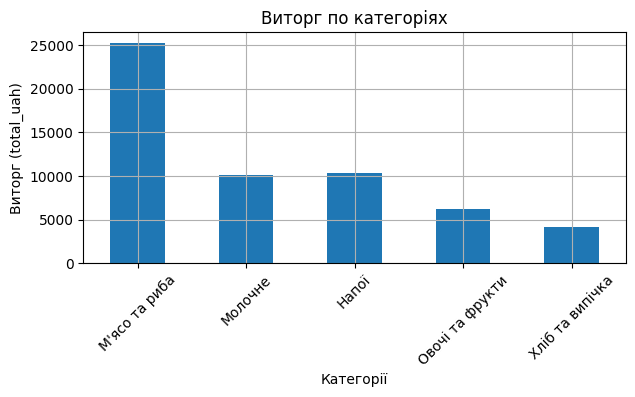

In [119]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7, 3))
df.groupby('category')['total_uah'].sum().plot(kind='bar')
plt.title("Виторг по категоріях")
plt.xlabel("Категорії")
plt.ylabel("Виторг (total_uah)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

2. Горизонтальна стовпчаста - топ-10 товарів за виторгом.

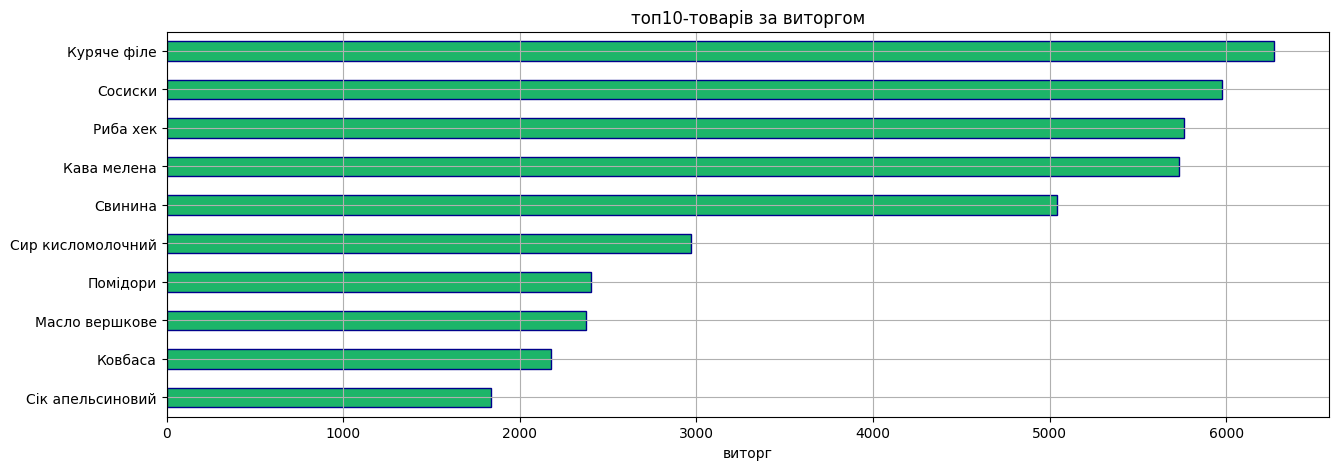

In [120]:
fig = plt.figure(figsize=(15, 5))

top10_revenue = (
    df.groupby('product')['total_uah']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

top10_revenue.plot(
    kind='barh',
    color='#1db569',
    edgecolor='darkblue'
)

plt.title("топ10-товарів за виторгом")
plt.xlabel("виторг")
plt.ylabel("")
plt.grid()
plt.show()

3. Кругова діаграма - розподіл способів оплати.

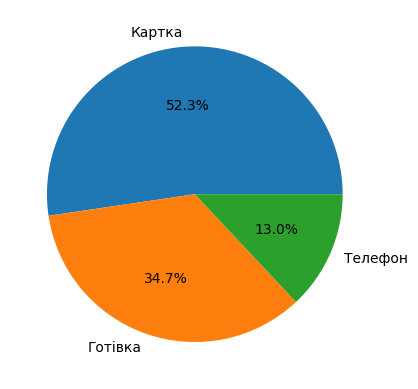

In [121]:
fig = plt.figure()
payment_count = df.payment.value_counts()
plt.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
plt.show()

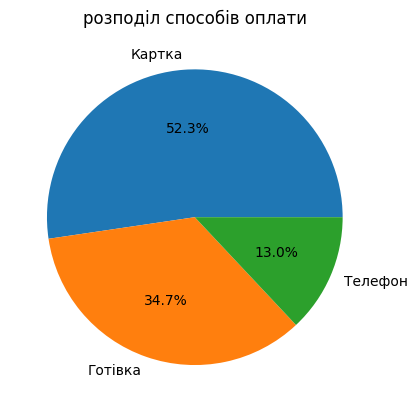

In [122]:
fig, ax = plt.subplots()
payment_count = df.payment.value_counts()
ax.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
ax.set_title('розподіл способів оплати')
plt.show()

4. Лінійний графік - виторг по днях березня.

<Axes: xlabel='day'>

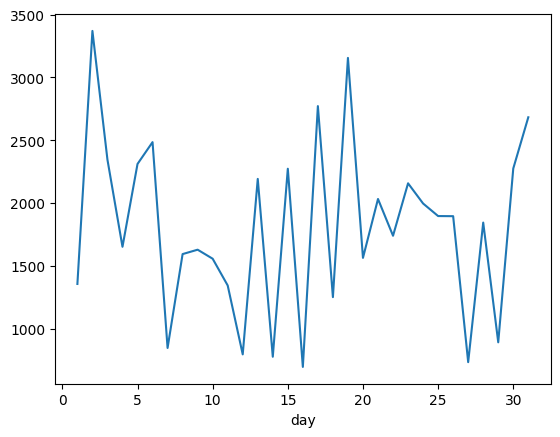

In [127]:
df.groupby('day')['total_uah'].sum().plot(kind='line')

In [128]:
df.groupby(['day', 'category'])['total_uah'].sum().unstack().head(10)

category,М'ясо та риба,Молочне,Напої,Овочі та фрукти,Хліб та випічка
day,,,,,
1,NaN,165.0,756.0,434.0,NaN
2,2209.0,255.0,375.0,472.0,60.0
3,1580.0,180.0,461.0,60.0,64.0
4,1320.0,114.0,162.0,NaN,55.0
5,630.0,305.0,811.0,175.0,390.0
6,1377.0,178.0,155.0,775.0,NaN
7,610.0,120.0,NaN,115.0,NaN
8,588.0,500.0,NaN,45.0,460.0
9,990.0,302.0,36.0,300.0,NaN


<Axes: xlabel='day'>

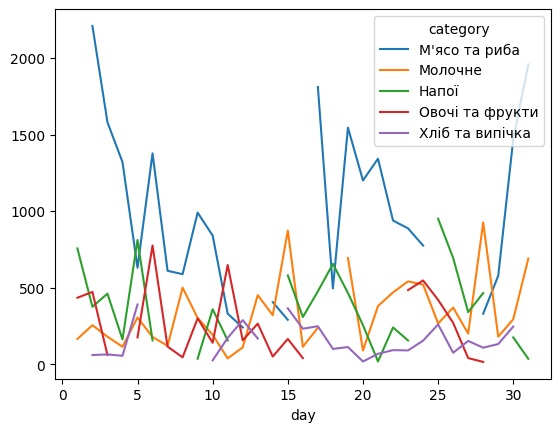

In [126]:
df.groupby(['day', 'category'])['total_uah'].sum().unstack().plot(kind='line')

margins

In [134]:
pivot = df.groupby(['day', 'category'])['total_uah'].sum().unstack()
pivot['total_sum_day'] = pivot.sum(axis=1)
pivot.loc['total_sum_category'] = pivot.sum(axis=0)
pivot

category,М'ясо та риба,Молочне,Напої,Овочі та фрукти,Хліб та випічка,total_sum_day
day,,,,,,
1,NaN,165.0,756.0,434.0,NaN,1355.0
2,2209.0,255.0,375.0,472.0,60.0,3371.0
3,1580.0,180.0,461.0,60.0,64.0,2345.0
4,1320.0,114.0,162.0,NaN,55.0,1651.0
5,630.0,305.0,811.0,175.0,390.0,2311.0
6,1377.0,178.0,155.0,775.0,NaN,2485.0
7,610.0,120.0,NaN,115.0,NaN,845.0
8,588.0,500.0,NaN,45.0,460.0,1593.0
9,990.0,302.0,36.0,300.0,NaN,1628.0


In [135]:
pd.pivot_table(
    df,
    values='total_uah',
    index='day',
    columns='category',
    aggfunc='sum',
    margins=True,
    margins_name='total_sum'
)

category,М'ясо та риба,Молочне,Напої,Овочі та фрукти,Хліб та випічка,total_sum
day,,,,,,
1,NaN,165.0,756.0,434.0,NaN,1355
2,2209.0,255.0,375.0,472.0,60.0,3371
3,1580.0,180.0,461.0,60.0,64.0,2345
4,1320.0,114.0,162.0,NaN,55.0,1651
5,630.0,305.0,811.0,175.0,390.0,2311
6,1377.0,178.0,155.0,775.0,NaN,2485
7,610.0,120.0,NaN,115.0,NaN,845
8,588.0,500.0,NaN,45.0,460.0,1593
9,990.0,302.0,36.0,300.0,NaN,1628


5. Гістограма - розподіл customer_age.

In [137]:
df.customer_age.value_counts()

,count
customer_age,
28,10
32,10
37,10
58,9
20,9
25,9
19,8
46,8
29,8


In [152]:
df['customer_age'].value_counts().mean()

np.float64(5.882352941176471)

[22. 14. 25. 20. 21. 24. 17. 21. 17. 22. 23. 20. 18. 16. 20.]


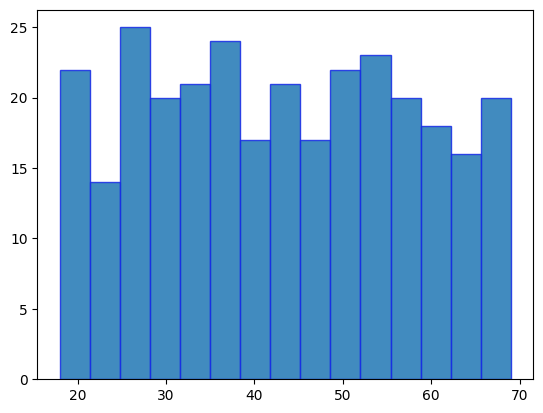

In [154]:
counts, bins, patches = plt.hist(
    df['customer_age'],
    bins=15,
    #color="",
    edgecolor="#162ae6",
    alpha=0.85
)

print(counts)
# print(bins)
# print(patches)

mean_counts = counts.mean()

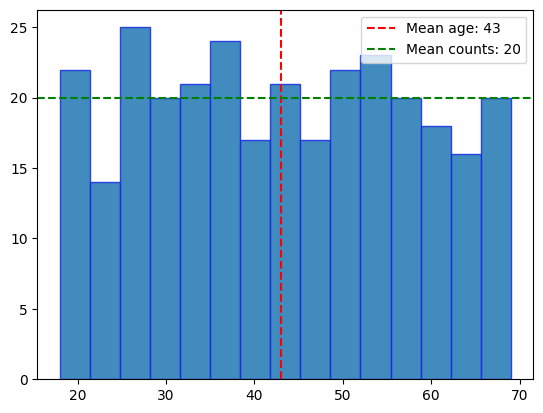

In [159]:
plt.hist(
    df['customer_age'],
    bins=15,
    #color="",
    edgecolor="#162ae6",
    alpha=0.85
)

# vertical line - red
plt.axvline(
    df['customer_age'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean age: {df['customer_age'].mean():.0f}"
)

# horizont line - green
plt.axhline(
    counts.mean(),
    color='green',
    linestyle='--',
    label=f"Mean counts: {counts.mean():.0f}"
)

plt.legend()
plt.show()

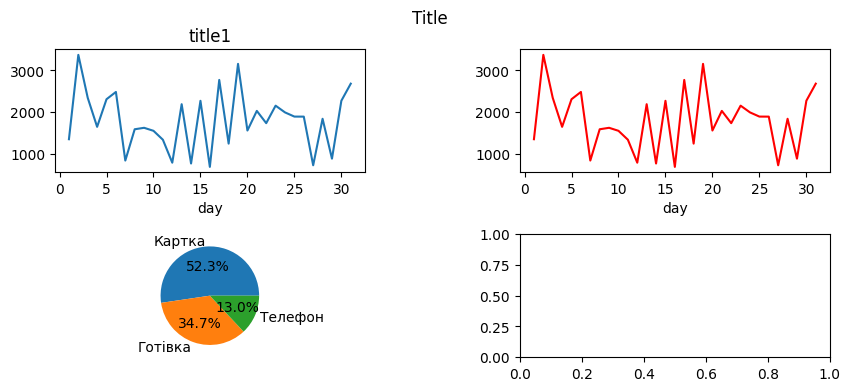

In [170]:
# plt.figure(figsize=(8, 3))
fig, axes = plt.subplots(2, 2, figsize=(10, 4))
fig.suptitle('Title')
plt.subplots_adjust(hspace=0.5, wspace=0.5)

ax1 = axes[0, 0]
ax1.set_title('title1')
df.groupby('day')['total_uah'].sum().plot(kind='line', ax=ax1)

ax2 = axes[0, 1]
df.groupby('day')['total_uah'].sum().plot(kind='line', color='red', ax=ax2)

ax3 = axes[1, 0]
payment_count = df.payment.value_counts()
ax3.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')

plt.savefig('figure.png')
plt.show()